In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
import os
import sys

# Project directory
PROJECT_DIR = "/content/selective-prediction-shift"
os.makedirs(PROJECT_DIR, exist_ok=True)

# Check core packages
import torch
import torchvision
import sklearn
import pandas as pd
import numpy as np
import matplotlib

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("scikit-learn:", sklearn.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Project directory:", PROJECT_DIR)


Python: 3.13.15
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
scikit-learn: 1.6.1
Pandas: 2.2.3
NumPy: 2.1.3
Project directory: /content/selective-prediction-shift


In [ ]:
from torchvision import datasets, transforms

DATA_DIR = os.path.join(PROJECT_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Number of classes:", len(train_dataset.classes))
print("Classes:", train_dataset.classes)

100%|██████████| 170M/170M [01:15<00:00, 2.27MB/s]


Training samples: 50000
Test samples: 10000
Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
from torch.utils.data import random_split

# Reproducible split
generator = torch.Generator().manual_seed(42)

train_dataset, calibration_dataset = random_split(
    train_dataset,
    [45000, 5000],
    generator=generator
)

print("Training samples:", len(train_dataset))
print("Calibration samples:", len(calibration_dataset))
print("Clean test samples:", len(test_dataset))

print("\nRandom split seed: 42")

Training samples: 45000
Calibration samples: 5000
Clean test samples: 10000

Random split seed: 42


In [ ]:
import torch.nn as nn
from torchvision.models import resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet18(weights=None)

# CIFAR-10 images are 32×32, so use a smaller initial convolution
# and remove the ImageNet-specific max pooling.
model.conv1 = nn.Conv2d(
    3, 64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)
model.maxpool = nn.Identity()

# CIFAR-10 has 10 classes
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

print("Device:", device)
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("Output classes:", model.fc.out_features)

Device: cuda
Parameters: 11173962
Output classes: 10


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Verify one batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


In [ ]:
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Training configuration
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Optimizer:", type(optimizer).__name__)
print("Scheduler:", type(scheduler).__name__)

Epochs: 30
Learning rate: 0.001
Weight decay: 0.0001
Optimizer: AdamW
Scheduler: CosineAnnealingLR


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


print("Training and evaluation functions defined successfully.")

Training and evaluation functions defined successfully.


In [9]:
import time

history = {
    "train_loss": [],
    "train_acc": [],
    "cal_loss": [],
    "cal_acc": []
}

best_cal_acc = 0.0
best_state = None

start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    cal_loss, cal_acc = evaluate(
        model, calibration_loader, criterion, device
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["cal_loss"].append(cal_loss)
    history["cal_acc"].append(cal_acc)

    if cal_acc > best_cal_acc:
        best_cal_acc = cal_acc
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Cal Acc: {cal_acc:.4f}"
    )

elapsed = time.time() - start_time

print(f"\nTraining complete in {elapsed / 60:.2f} minutes")
print(f"Best calibration accuracy: {best_cal_acc:.4f}")

Epoch 01/30 | Train Loss: 1.2550 | Train Acc: 0.5431 | Cal Acc: 0.6286
Epoch 02/30 | Train Loss: 0.7607 | Train Acc: 0.7310 | Cal Acc: 0.7252
Epoch 03/30 | Train Loss: 0.5612 | Train Acc: 0.8030 | Cal Acc: 0.7654
Epoch 04/30 | Train Loss: 0.4240 | Train Acc: 0.8540 | Cal Acc: 0.7472
Epoch 05/30 | Train Loss: 0.3146 | Train Acc: 0.8889 | Cal Acc: 0.7976
Epoch 06/30 | Train Loss: 0.2224 | Train Acc: 0.9230 | Cal Acc: 0.8046
Epoch 07/30 | Train Loss: 0.1517 | Train Acc: 0.9478 | Cal Acc: 0.7848
Epoch 08/30 | Train Loss: 0.1030 | Train Acc: 0.9642 | Cal Acc: 0.8254
Epoch 09/30 | Train Loss: 0.0687 | Train Acc: 0.9756 | Cal Acc: 0.8262
Epoch 10/30 | Train Loss: 0.0501 | Train Acc: 0.9831 | Cal Acc: 0.8252
Epoch 11/30 | Train Loss: 0.0495 | Train Acc: 0.9824 | Cal Acc: 0.8400
Epoch 12/30 | Train Loss: 0.0281 | Train Acc: 0.9904 | Cal Acc: 0.8400
Epoch 13/30 | Train Loss: 0.0205 | Train Acc: 0.9930 | Cal Acc: 0.8400
Epoch 14/30 | Train Loss: 0.0171 | Train Acc: 0.9946 | Cal Acc: 0.8456
Epoch 

In [10]:
# Restore the checkpoint with the best calibration accuracy
model.load_state_dict(best_state)
model = model.to(device)

test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Best calibration accuracy: {best_cal_acc:.4f}")
print(f"Clean test loss: {test_loss:.4f}")
print(f"Clean test accuracy: {test_acc:.4f}")

Best calibration accuracy: 0.8694
Clean test loss: 0.7995
Clean test accuracy: 0.8608


In [11]:
@torch.no_grad()
def collect_logits(model, loader, device):
    model.eval()

    all_logits = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)

        logits = model(images)

        all_logits.append(logits.cpu())
        all_labels.append(labels)

    return (
        torch.cat(all_logits),
        torch.cat(all_labels)
    )


cal_logits, cal_labels = collect_logits(
    model, calibration_loader, device
)

test_logits, test_labels = collect_logits(
    model, test_loader, device
)

print("Calibration logits:", cal_logits.shape)
print("Calibration labels:", cal_labels.shape)
print("Test logits:", test_logits.shape)
print("Test labels:", test_labels.shape)

Calibration logits: torch.Size([5000, 10])
Calibration labels: torch.Size([5000])
Test logits: torch.Size([10000, 10])
Test labels: torch.Size([10000])


In [12]:
import torch.nn.functional as F

def get_confidence(logits, labels):
    probabilities = F.softmax(logits, dim=1)

    confidence, predictions = probabilities.max(dim=1)
    correct = predictions.eq(labels)

    return confidence, predictions, correct


cal_conf, cal_preds, cal_correct = get_confidence(
    cal_logits, cal_labels
)

test_conf, test_preds, test_correct = get_confidence(
    test_logits, test_labels
)

print("Calibration set")
print(f"  Accuracy:   {cal_correct.float().mean().item():.4f}")
print(f"  Mean confidence: {cal_conf.mean().item():.4f}")

print("\nClean test set")
print(f"  Accuracy:   {test_correct.float().mean().item():.4f}")
print(f"  Mean confidence: {test_conf.mean().item():.4f}")

print("\nConfidence range (test)")
print(f"  Min: {test_conf.min().item():.4f}")
print(f"  Max: {test_conf.max().item():.4f}")

Calibration set
  Accuracy:   0.8694
  Mean confidence: 0.9666

Clean test set
  Accuracy:   0.8608
  Mean confidence: 0.9638

Confidence range (test)
  Min: 0.3327
  Max: 1.0000


In [13]:
from torch.optim import LBFGS

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature


temperature_model = TemperatureScaler()

optimizer_temp = LBFGS(
    [temperature_model.temperature],
    lr=0.01,
    max_iter=100,
    line_search_fn="strong_wolfe"
)

def temperature_closure():
    optimizer_temp.zero_grad()

    scaled_logits = temperature_model(cal_logits)
    loss = F.cross_entropy(scaled_logits, cal_labels)

    loss.backward()
    return loss


optimizer_temp.step(temperature_closure)

T = temperature_model.temperature.item()

print(f"Learned temperature T: {T:.4f}")

if T > 1:
    print("T > 1 → confidence is being softened.")
elif T < 1:
    print("T < 1 → confidence is being sharpened.")
else:
    print("T ≈ 1 → little calibration adjustment.")

Learned temperature T: 2.9429
T > 1 → confidence is being softened.


In [14]:
# Apply the learned temperature to the clean test logits
calibrated_test_logits = test_logits / T
calibrated_test_probs = F.softmax(calibrated_test_logits, dim=1)

calibrated_conf, calibrated_preds = calibrated_test_probs.max(dim=1)
calibrated_correct = calibrated_preds.eq(test_labels)

print("Clean test — before vs after temperature scaling")
print(f"Accuracy:          {test_correct.float().mean().item():.4f} → "
      f"{calibrated_correct.float().mean().item():.4f}")

print(f"Mean confidence:   {test_conf.mean().item():.4f} → "
      f"{calibrated_conf.mean().item():.4f}")

print(f"Mean confidence (correct): "
      f"{test_conf[test_correct].mean().item():.4f} → "
      f"{calibrated_conf[calibrated_correct].mean().item():.4f}")

print(f"Mean confidence (wrong):   "
      f"{test_conf[~test_correct].mean().item():.4f} → "
      f"{calibrated_conf[~calibrated_correct].mean().item():.4f}")

Clean test — before vs after temperature scaling
Accuracy:          0.8608 → 0.8608
Mean confidence:   0.9638 → 0.8735
Mean confidence (correct): 0.9808 → 0.9129
Mean confidence (wrong):   0.8591 → 0.6300


In [16]:
import requests

url = "https://zenodo.org/records/2535967"

response = requests.get(url)

print("Status:", response.status_code)
print("Final URL:", response.url)
print("Page accessible:", response.ok)

Status: 200
Final URL: https://zenodo.org/records/2535967
Page accessible: True


In [17]:
import requests

api_url = "https://zenodo.org/api/records/2535967"

response = requests.get(api_url)
print("Status:", response.status_code)

record = response.json()

print("\nAvailable files:")
for f in record["files"]:
    print(f["key"], "→", f["links"]["self"])

Status: 200

Available files:
CIFAR-10-C.tar → https://zenodo.org/api/records/2535967/files/CIFAR-10-C.tar/content
CIFAR-10-P.tar → https://zenodo.org/api/records/2535967/files/CIFAR-10-P.tar/content


In [18]:
import requests
import tarfile
import os

tar_path = os.path.join(DATA_DIR, "CIFAR-10-C.tar")
extract_dir = os.path.join(DATA_DIR, "cifar10-c")

os.makedirs(extract_dir, exist_ok=True)

url = "https://zenodo.org/api/records/2535967/files/CIFAR-10-C.tar/content"

if not os.path.exists(tar_path):
    print("Downloading CIFAR-10-C...")

    with requests.get(url, stream=True) as r:
        r.raise_for_status()

        total = int(r.headers.get("content-length", 0))
        downloaded = 0

        with open(tar_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)

                    if total:
                        percent = 100 * downloaded / total
                        print(
                            f"\rProgress: {percent:.1f}%",
                            end=""
                        )

    print("\nDownload complete.")
else:
    print("Archive already downloaded.")

print("Extracting...")

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(DATA_DIR)

print("Extraction complete.")

# Locate extracted directory
for root, dirs, files in os.walk(DATA_DIR):
    if "labels.npy" in files:
        print("\nCIFAR-10-C found at:", root)
        print("Files:", len(files))
        break

Progress: 39.8%

KeyboardInterrupt: 

In [19]:
!pip -q install datasets

In [20]:
from datasets import load_dataset

print("datasets package ready.")

datasets package ready.


In [21]:
from datasets import load_dataset

shifted = load_dataset(
    "WNJXYK/TTA-CIFAR-10-C",
    "gaussian_noise",
    split="test"
)

print(shifted)
print("\nColumns:", shifted.column_names)
print("Number of samples:", len(shifted))

README.md:   0%|          | 0.00/8.03k [00:00<?, ?B/s]

data/gaussian_noise/severity_1/data-0000(…): reconstructing file:   0%|          |  0.00B / 26.7MB            

data/gaussian_noise/severity_1/data-0000(…): downloading bytes:           |  0.00B            

data/gaussian_noise/severity_2/data-0000(…): reconstructing file:   0%|          |  0.00B / 28.1MB            

data/gaussian_noise/severity_2/data-0000(…): downloading bytes:           |  0.00B            

...

Generating severity_2 split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating severity_3 split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating severity_4 split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating severity_5 split:   0%|          | 0/10000 [00:00<?, ? examples/s]

ValueError: Unknown split "test". Should be one of ['severity_1', 'severity_2', 'severity_3', 'severity_4', 'severity_5'].

In [22]:
shifted = load_dataset(
    "WNJXYK/TTA-CIFAR-10-C",
    "gaussian_noise",
    split="severity_5"
)

print(shifted)
print("\nColumns:", shifted.column_names)
print("Number of samples:", len(shifted))

sample = shifted[0]

print("\nFirst sample:")
print(sample)

Dataset({
    features: ['image', 'label'],
    num_rows: 10000
})

Columns: ['image', 'label']
Number of samples: 10000

First sample:
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x7F933D5CE510>, 'label': 3}


In [23]:
from torch.utils.data import Dataset, DataLoader

class CIFAR10CWrapper(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset
        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        image = self.transform(item["image"])
        label = torch.tensor(item["label"], dtype=torch.long)

        return image, label


shifted_dataset = CIFAR10CWrapper(shifted)

shifted_loader = DataLoader(
    shifted_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(shifted_loader))

print("Shifted dataset:", len(shifted_dataset))
print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Shifted dataset: 10000
Batch shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


In [24]:
shifted_logits, shifted_labels = collect_logits(
    model,
    shifted_loader,
    device
)

shifted_conf, shifted_preds, shifted_correct = get_confidence(
    shifted_logits,
    shifted_labels
)

print("Gaussian Noise — Severity 5")
print(f"Accuracy:              {shifted_correct.float().mean().item():.4f}")
print(f"Mean confidence:       {shifted_conf.mean().item():.4f}")
print(f"Mean confidence (correct): "
      f"{shifted_conf[shifted_correct].mean().item():.4f}")
print(f"Mean confidence (wrong):   "
      f"{shifted_conf[~shifted_correct].mean().item():.4f}")

print("\nClean → Shifted")
print(f"Accuracy:        "
      f"{test_correct.float().mean().item():.4f} → "
      f"{shifted_correct.float().mean().item():.4f}")
print(f"Mean confidence: "
      f"{test_conf.mean().item():.4f} → "
      f"{shifted_conf.mean().item():.4f}")


Gaussian Noise — Severity 5
Accuracy:              0.4123
Mean confidence:       0.9130
Mean confidence (correct): 0.9416
Mean confidence (wrong):   0.8930

Clean → Shifted
Accuracy:        0.8608 → 0.4123
Mean confidence: 0.9638 → 0.9130


In [25]:
# Apply the temperature learned ONLY on the clean calibration set
calibrated_shifted_logits = shifted_logits / T
calibrated_shifted_probs = F.softmax(
    calibrated_shifted_logits,
    dim=1
)

calibrated_shifted_conf, calibrated_shifted_preds = (
    calibrated_shifted_probs.max(dim=1)
)

calibrated_shifted_correct = calibrated_shifted_preds.eq(
    shifted_labels
)

print("Gaussian Noise — Severity 5")
print("\nAccuracy")
print(f"Raw:        {shifted_correct.float().mean().item():.4f}")
print(f"Calibrated: {calibrated_shifted_correct.float().mean().item():.4f}")

print("\nMean confidence")
print(f"Raw:        {shifted_conf.mean().item():.4f}")
print(f"Calibrated: {calibrated_shifted_conf.mean().item():.4f}")

print("\nConfidence on WRONG predictions")
print(f"Raw:        {shifted_conf[~shifted_correct].mean().item():.4f}")
print(f"Calibrated: "
      f"{calibrated_shifted_conf[~calibrated_shifted_correct].mean().item():.4f}")

print("\nConfidence on CORRECT predictions")
print(f"Raw:        {shifted_conf[shifted_correct].mean().item():.4f}")
print(f"Calibrated: "
      f"{calibrated_shifted_conf[calibrated_shifted_correct].mean().item():.4f}")

Gaussian Noise — Severity 5

Accuracy
Raw:        0.4123
Calibrated: 0.4123

Mean confidence
Raw:        0.9130
Calibrated: 0.7340

Confidence on WRONG predictions
Raw:        0.8930
Calibrated: 0.6869

Confidence on CORRECT predictions
Raw:        0.9416
Calibrated: 0.8011


In [26]:
import numpy as np

def risk_coverage_curve(confidence, correct):
    """
    Sort predictions by confidence and progressively
    accept the most confident predictions.

    Coverage = fraction of predictions we keep.
    Risk = error rate among the predictions we keep.
    """

    confidence = confidence.detach().cpu().numpy()
    correct = correct.detach().cpu().numpy().astype(bool)

    # Highest confidence first
    order = np.argsort(-confidence)
    sorted_correct = correct[order]

    n = len(sorted_correct)

    coverage = np.arange(1, n + 1) / n
    cumulative_correct = np.cumsum(sorted_correct)

    accuracy = cumulative_correct / np.arange(1, n + 1)
    risk = 1.0 - accuracy

    return coverage, risk


raw_coverage, raw_risk = risk_coverage_curve(
    shifted_conf,
    shifted_correct
)

cal_coverage, cal_risk = risk_coverage_curve(
    calibrated_shifted_conf,
    calibrated_shifted_correct
)

print("Risk–coverage curves computed.")
print(f"Raw curve points: {len(raw_coverage)}")
print(f"Calibrated curve points: {len(cal_coverage)}")

# Show risk at useful coverage levels
for target_coverage in [1.0, 0.9, 0.8, 0.7, 0.5]:
    idx = np.argmin(
        np.abs(raw_coverage - target_coverage)
    )

    print(
        f"Coverage {raw_coverage[idx]:.2f} | "
        f"Raw risk: {raw_risk[idx]:.4f} | "
        f"Calibrated risk: {cal_risk[idx]:.4f}"
    )

Risk–coverage curves computed.
Raw curve points: 10000
Calibrated curve points: 10000
Coverage 1.00 | Raw risk: 0.5877 | Calibrated risk: 0.5877
Coverage 0.90 | Raw risk: 0.5712 | Calibrated risk: 0.5677
Coverage 0.80 | Raw risk: 0.5544 | Calibrated risk: 0.5495
Coverage 0.70 | Raw risk: 0.5337 | Calibrated risk: 0.5286
Coverage 0.50 | Raw risk: 0.4854 | Calibrated risk: 0.4810


In [27]:
# Temperature scaling should NOT change the predicted class.
same_predictions = torch.equal(
    shifted_preds,
    calibrated_shifted_preds
)

# More importantly, it should preserve the ranking of examples
# by maximum confidence.
raw_order = torch.argsort(shifted_conf, descending=True)
cal_order = torch.argsort(
    calibrated_shifted_conf,
    descending=True
)

same_ranking = torch.equal(raw_order, cal_order)

print("Same predictions:", same_predictions)
print("Same confidence ranking:", same_ranking)

# Check how much the actual confidence values changed
print(
    "Mean absolute confidence change:",
    torch.abs(
        shifted_conf - calibrated_shifted_conf
    ).mean().item()
)

Same predictions: True
Same confidence ranking: False
Mean absolute confidence change: 0.1790449172258377


In [28]:
from sklearn.metrics import auc

def compute_aurc(coverage, risk):
    return auc(coverage, risk)


raw_aurc = compute_aurc(raw_coverage, raw_risk)
cal_aurc = compute_aurc(cal_coverage, cal_risk)

print(f"Raw AURC:        {raw_aurc:.6f}")
print(f"Calibrated AURC: {cal_aurc:.6f}")

improvement = raw_aurc - cal_aurc

print(f"Difference:      {improvement:.6f}")
print(f"Relative change: {100 * improvement / raw_aurc:.2f}%")

Raw AURC:        0.445232
Calibrated AURC: 0.434698
Difference:      0.010534
Relative change: 2.37%


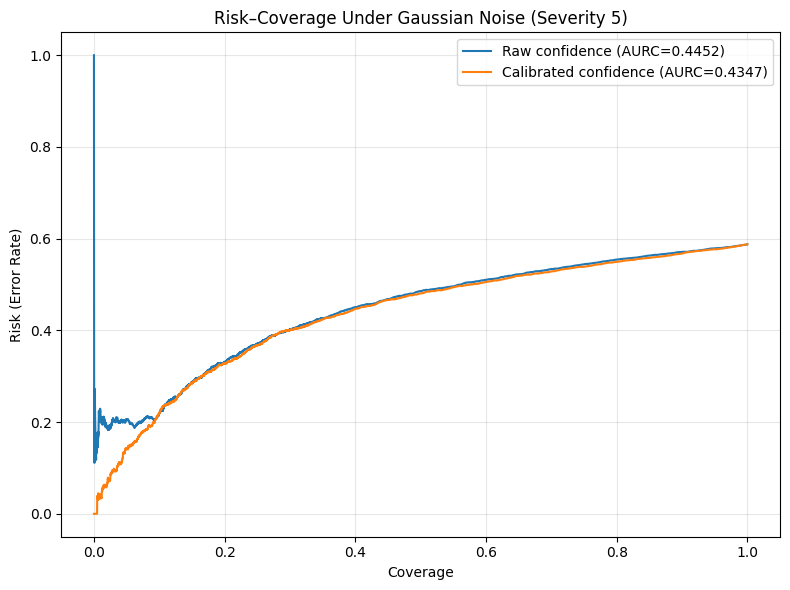

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    raw_coverage,
    raw_risk,
    label=f"Raw confidence (AURC={raw_aurc:.4f})"
)

plt.plot(
    cal_coverage,
    cal_risk,
    label=f"Calibrated confidence (AURC={cal_aurc:.4f})"
)

plt.xlabel("Coverage")
plt.ylabel("Risk (Error Rate)")
plt.title("Risk–Coverage Under Gaussian Noise (Severity 5)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
severity_results = []

for severity in range(1, 6):

    print(f"\nEvaluating Gaussian Noise — Severity {severity}")

    severity_dataset = load_dataset(
        "WNJXYK/TTA-CIFAR-10-C",
        "gaussian_noise",
        split=f"severity_{severity}"
    )

    severity_wrapped = CIFAR10CWrapper(severity_dataset)

    severity_loader = DataLoader(
        severity_wrapped,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # Get model logits
    logits, labels = collect_logits(
        model,
        severity_loader,
        device
    )

    # Raw confidence
    conf, preds, correct = get_confidence(
        logits,
        labels
    )

    # Calibrated confidence
    calibrated_logits = logits / T
    calibrated_probs = F.softmax(calibrated_logits, dim=1)

    cal_conf, cal_preds = calibrated_probs.max(dim=1)
    cal_correct = cal_preds.eq(labels)

    # Risk-coverage
    raw_cov, raw_risk = risk_coverage_curve(
        conf, correct
    )

    cal_cov, cal_risk = risk_coverage_curve(
        cal_conf, cal_correct
    )

    raw_aurc = compute_aurc(raw_cov, raw_risk)
    cal_aurc = compute_aurc(cal_cov, cal_risk)

    result = {
        "severity": severity,
        "accuracy": correct.float().mean().item(),
        "raw_confidence": conf.mean().item(),
        "calibrated_confidence": cal_conf.mean().item(),
        "raw_aurc": raw_aurc,
        "calibrated_aurc": cal_aurc,
    }

    severity_results.append(result)

    print(
        f"Accuracy: {result['accuracy']:.4f} | "
        f"Raw Conf: {result['raw_confidence']:.4f} | "
        f"Cal Conf: {result['calibrated_confidence']:.4f} | "
        f"Raw AURC: {result['raw_aurc']:.4f} | "
        f"Cal AURC: {result['calibrated_aurc']:.4f}"
    )


Evaluating Gaussian Noise — Severity 1
Accuracy: 0.7774 | Raw Conf: 0.9482 | Cal Conf: 0.8262 | Raw AURC: 0.0675 | Cal AURC: 0.0658

Evaluating Gaussian Noise — Severity 2
Accuracy: 0.6689 | Raw Conf: 0.9301 | Cal Conf: 0.7808 | Raw AURC: 0.1502 | Cal AURC: 0.1461

Evaluating Gaussian Noise — Severity 3
Accuracy: 0.5364 | Raw Conf: 0.9179 | Cal Conf: 0.7478 | Raw AURC: 0.2935 | Cal AURC: 0.2852

Evaluating Gaussian Noise — Severity 4
Accuracy: 0.4689 | Raw Conf: 0.9140 | Cal Conf: 0.7373 | Raw AURC: 0.3707 | Cal AURC: 0.3609

Evaluating Gaussian Noise — Severity 5
Accuracy: 0.4123 | Raw Conf: 0.9130 | Cal Conf: 0.7340 | Raw AURC: 0.4452 | Cal AURC: 0.4347


In [31]:
from sklearn.metrics import brier_score_loss


def expected_calibration_error(confidence, correct, n_bins=15):
    """
    Expected Calibration Error (ECE).

    Groups predictions by confidence and measures the
    difference between confidence and empirical accuracy.
    """

    confidence = confidence.detach().cpu().numpy()
    correct = correct.detach().cpu().numpy().astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:
            mask = (confidence >= lower) & (confidence <= upper)
        else:
            mask = (confidence >= lower) & (confidence < upper)

        if mask.sum() == 0:
            continue

        bin_accuracy = correct[mask].mean()
        bin_confidence = confidence[mask].mean()
        bin_fraction = mask.mean()

        ece += bin_fraction * abs(
            bin_accuracy - bin_confidence
        )

    return ece


def multiclass_brier_score(logits, labels):
    """
    Multiclass Brier score:
    mean squared error between predicted probabilities
    and the one-hot true labels.
    """

    probabilities = F.softmax(logits, dim=1).cpu().numpy()
    labels_np = labels.cpu().numpy()

    one_hot = np.zeros_like(probabilities)
    one_hot[np.arange(len(labels_np)), labels_np] = 1

    return np.mean(np.sum((probabilities - one_hot) ** 2, axis=1))


# Clean test
raw_clean_ece = expected_calibration_error(
    test_conf,
    test_correct
)

cal_clean_ece = expected_calibration_error(
    calibrated_conf,
    calibrated_correct
)

raw_clean_brier = multiclass_brier_score(
    test_logits,
    test_labels
)

cal_clean_brier = multiclass_brier_score(
    calibrated_test_logits,
    test_labels
)

print("CLEAN TEST")
print(f"Raw ECE:        {raw_clean_ece:.4f}")
print(f"Calibrated ECE: {cal_clean_ece:.4f}")
print(f"Raw Brier:      {raw_clean_brier:.4f}")
print(f"Cal Brier:      {cal_clean_brier:.4f}")


print("\nGAUSSIAN NOISE")

for result in severity_results:
    severity = result["severity"]

    severity_dataset = load_dataset(
        "WNJXYK/TTA-CIFAR-10-C",
        "gaussian_noise",
        split=f"severity_{severity}"
    )

    severity_wrapped = CIFAR10CWrapper(severity_dataset)

    severity_loader = DataLoader(
        severity_wrapped,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    logits, labels = collect_logits(
        model,
        severity_loader,
        device
    )

    conf, preds, correct = get_confidence(
        logits,
        labels
    )

    calibrated_logits = logits / T
    calibrated_probs = F.softmax(
        calibrated_logits,
        dim=1
    )

    cal_conf, cal_preds = calibrated_probs.max(dim=1)
    cal_correct = cal_preds.eq(labels)

    raw_ece = expected_calibration_error(
        conf,
        correct
    )

    cal_ece = expected_calibration_error(
        cal_conf,
        cal_correct
    )

    raw_brier = multiclass_brier_score(
        logits,
        labels
    )

    cal_brier = multiclass_brier_score(
        calibrated_logits,
        labels
    )

    result["raw_ece"] = raw_ece
    result["calibrated_ece"] = cal_ece
    result["raw_brier"] = raw_brier
    result["calibrated_brier"] = cal_brier

    print(
        f"Severity {severity} | "
        f"ECE: {raw_ece:.4f} → {cal_ece:.4f} | "
        f"Brier: {raw_brier:.4f} → {cal_brier:.4f}"
    )

CLEAN TEST
Raw ECE:        0.1032
Calibrated ECE: 0.0155
Raw Brier:      0.2375
Cal Brier:      0.2015

GAUSSIAN NOISE
Severity 1 | ECE: 0.1708 → 0.0488 | Brier: 0.3811 → 0.3137
Severity 2 | ECE: 0.2613 → 0.1120 | Brier: 0.5735 → 0.4726
Severity 3 | ECE: 0.3815 → 0.2119 | Brier: 0.8216 → 0.6744
Severity 4 | ECE: 0.4453 → 0.2687 | Brier: 0.9471 → 0.7738
Severity 5 | ECE: 0.5009 → 0.3218 | Brier: 1.0531 → 0.8625


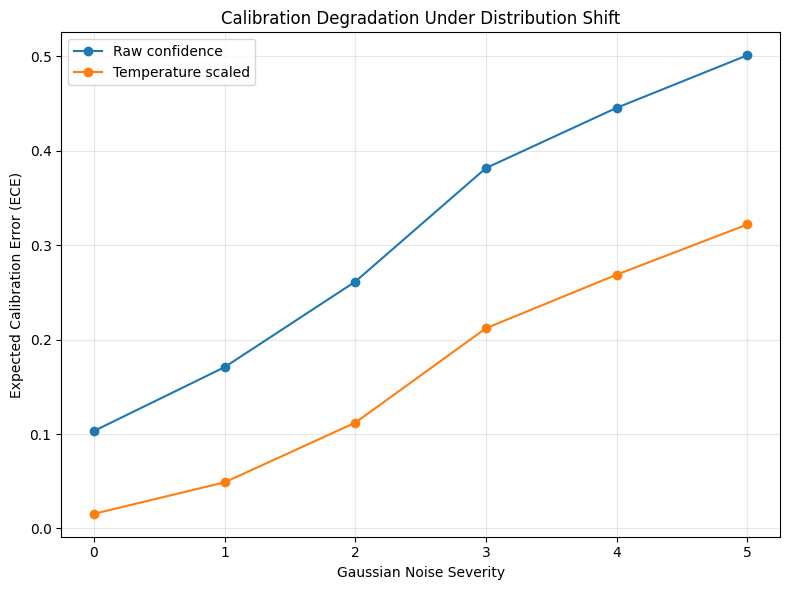

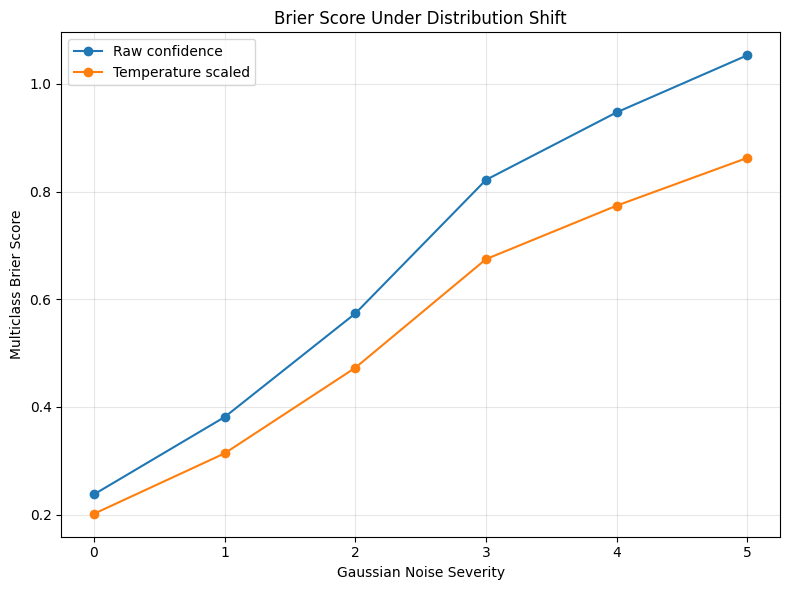

In [32]:
severities = [r["severity"] for r in severity_results]

raw_ece = [r["raw_ece"] for r in severity_results]
cal_ece = [r["calibrated_ece"] for r in severity_results]

raw_brier = [r["raw_brier"] for r in severity_results]
cal_brier = [r["calibrated_brier"] for r in severity_results]

# Include clean test as severity 0
x = [0] + severities

ece_raw = [raw_clean_ece] + raw_ece
ece_cal = [cal_clean_ece] + cal_ece

brier_raw = [raw_clean_brier] + raw_brier
brier_cal = [cal_clean_brier] + cal_brier


# ---- ECE plot ----
plt.figure(figsize=(8, 6))

plt.plot(
    x,
    ece_raw,
    marker="o",
    label="Raw confidence"
)

plt.plot(
    x,
    ece_cal,
    marker="o",
    label="Temperature scaled"
)

plt.xlabel("Gaussian Noise Severity")
plt.ylabel("Expected Calibration Error (ECE)")
plt.title("Calibration Degradation Under Distribution Shift")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ---- Brier score plot ----
plt.figure(figsize=(8, 6))

plt.plot(
    x,
    brier_raw,
    marker="o",
    label="Raw confidence"
)

plt.plot(
    x,
    brier_cal,
    marker="o",
    label="Temperature scaled"
)

plt.xlabel("Gaussian Noise Severity")
plt.ylabel("Multiclass Brier Score")
plt.title("Brier Score Under Distribution Shift")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import roc_auc_score, average_precision_score

def error_detection_metrics(confidence, correct):
    confidence = confidence.detach().cpu().numpy()
    correct = correct.detach().cpu().numpy().astype(int)

    # 1 = prediction is wrong
    error = 1 - correct

    # Higher score should mean "more likely to be wrong"
    error_score = 1.0 - confidence

    auroc = roc_auc_score(error, error_score)
    ap = average_precision_score(error, error_score)

    return auroc, ap


error_results = []

# Clean test
raw_auroc, raw_ap = error_detection_metrics(
    test_conf,
    test_correct
)

cal_auroc, cal_ap = error_detection_metrics(
    calibrated_conf,
    calibrated_correct
)

error_results.append({
    "severity": 0,
    "raw_auroc": raw_auroc,
    "calibrated_auroc": cal_auroc,
    "raw_ap": raw_ap,
    "calibrated_ap": cal_ap
})

print(
    f"Clean | "
    f"AUROC: {raw_auroc:.4f} → {cal_auroc:.4f} | "
    f"AP: {raw_ap:.4f} → {cal_ap:.4f}"
)


# Gaussian noise severities
for severity in range(1, 6):

    severity_dataset = load_dataset(
        "WNJXYK/TTA-CIFAR-10-C",
        "gaussian_noise",
        split=f"severity_{severity}"
    )

    severity_wrapped = CIFAR10CWrapper(severity_dataset)

    severity_loader = DataLoader(
        severity_wrapped,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    logits, labels = collect_logits(
        model,
        severity_loader,
        device
    )

    conf, preds, correct = get_confidence(
        logits,
        labels
    )

    calibrated_logits = logits / T
    calibrated_probs = F.softmax(
        calibrated_logits,
        dim=1
    )

    cal_conf, cal_preds = calibrated_probs.max(dim=1)
    cal_correct = cal_preds.eq(labels)

    raw_auroc, raw_ap = error_detection_metrics(
        conf,
        correct
    )

    cal_auroc, cal_ap = error_detection_metrics(
        cal_conf,
        cal_correct
    )

    error_results.append({
        "severity": severity,
        "raw_auroc": raw_auroc,
        "calibrated_auroc": cal_auroc,
        "raw_ap": raw_ap,
        "calibrated_ap": cal_ap
    })

    print(
        f"Severity {severity} | "
        f"AUROC: {raw_auroc:.4f} → {cal_auroc:.4f} | "
        f"AP: {raw_ap:.4f} → {cal_ap:.4f}"
    )

Clean | AUROC: 0.8843 → 0.8874 | AP: 0.5043 → 0.5218
Severity 1 | AUROC: 0.8446 → 0.8500 | AP: 0.5583 → 0.5779
Severity 2 | AUROC: 0.7822 → 0.7883 | AP: 0.5961 → 0.6063
Severity 3 | AUROC: 0.7070 → 0.7148 | AP: 0.6359 → 0.6492
Severity 4 | AUROC: 0.6836 → 0.6920 | AP: 0.6716 → 0.6852
Severity 5 | AUROC: 0.6574 → 0.6656 | AP: 0.6998 → 0.7113


In [34]:
def risk_at_coverage(confidence, correct, target_coverage):
    confidence = confidence.detach().cpu().numpy()
    correct = correct.detach().cpu().numpy().astype(bool)

    n = len(confidence)
    k = max(1, int(n * target_coverage))

    # Keep highest-confidence predictions
    order = np.argsort(-confidence)
    selected = correct[order[:k]]

    risk = 1.0 - selected.mean()

    return risk


coverage_levels = [0.10, 0.25, 0.50, 0.75, 0.90]

# ---------------------------------------------------------
# Clean
# ---------------------------------------------------------

print("CLEAN TEST")

for coverage in coverage_levels:

    raw_risk = risk_at_coverage(
        test_conf,
        test_correct,
        coverage
    )

    cal_risk = risk_at_coverage(
        calibrated_conf,
        calibrated_correct,
        coverage
    )

    print(
        f"Coverage {coverage:.0%} | "
        f"Risk: {raw_risk:.4f} → {cal_risk:.4f}"
    )


# ---------------------------------------------------------
# Gaussian noise
# ---------------------------------------------------------

print("\nGAUSSIAN NOISE")

for severity in range(1, 6):

    severity_dataset = load_dataset(
        "WNJXYK/TTA-CIFAR-10-C",
        "gaussian_noise",
        split=f"severity_{severity}"
    )

    severity_wrapped = CIFAR10CWrapper(severity_dataset)

    severity_loader = DataLoader(
        severity_wrapped,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    logits, labels = collect_logits(
        model,
        severity_loader,
        device
    )

    # Raw
    conf, preds, correct = get_confidence(
        logits,
        labels
    )

    # Calibrated
    calibrated_logits = logits / T
    calibrated_probs = F.softmax(
        calibrated_logits,
        dim=1
    )

    cal_conf, cal_preds = calibrated_probs.max(dim=1)
    cal_correct = cal_preds.eq(labels)

    print(f"\nSeverity {severity}")

    for coverage in coverage_levels:

        raw_risk = risk_at_coverage(
            conf,
            correct,
            coverage
        )

        cal_risk = risk_at_coverage(
            cal_conf,
            cal_correct,
            coverage
        )

        print(
            f"Coverage {coverage:.0%} | "
            f"Risk: {raw_risk:.4f} → {cal_risk:.4f}"
        )

CLEAN TEST
Coverage 10% | Risk: 0.0020 → 0.0000
Coverage 25% | Risk: 0.0032 → 0.0004
Coverage 50% | Risk: 0.0096 → 0.0098
Coverage 75% | Risk: 0.0431 → 0.0432
Coverage 90% | Risk: 0.0934 → 0.0919

GAUSSIAN NOISE

Severity 1
Coverage 10% | Risk: 0.0060 → 0.0020
Coverage 25% | Risk: 0.0088 → 0.0080
Coverage 50% | Risk: 0.0422 → 0.0408
Coverage 75% | Risk: 0.1140 → 0.1131
Coverage 90% | Risk: 0.1784 → 0.1758

Severity 2
Coverage 10% | Risk: 0.0280 → 0.0150
Coverage 25% | Risk: 0.0528 → 0.0508
Coverage 50% | Risk: 0.1420 → 0.1394
Coverage 75% | Risk: 0.2340 → 0.2305
Coverage 90% | Risk: 0.2962 → 0.2926

Severity 3
Coverage 10% | Risk: 0.1030 → 0.0960
Coverage 25% | Risk: 0.1972 → 0.1908
Coverage 50% | Risk: 0.3146 → 0.3116
Coverage 75% | Risk: 0.3973 → 0.3915
Coverage 90% | Risk: 0.4378 → 0.4341

Severity 4
Coverage 10% | Risk: 0.1440 → 0.1320
Coverage 25% | Risk: 0.2844 → 0.2792
Coverage 50% | Risk: 0.3982 → 0.3934
Coverage 75% | Risk: 0.4767 → 0.4711
Coverage 90% | Risk: 0.5092 → 0.5073


In [36]:
import json
import os
import numpy as np

def make_json_serializable(obj):
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj


results = {
    "model": {
        "architecture": "ResNet18",
        "parameters": 11173962,
        "epochs": 30,
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "seed": 42
    },

    "data": {
        "dataset": "CIFAR-10",
        "train_samples": 45000,
        "calibration_samples": 5000,
        "clean_test_samples": 10000,
        "shift": "Gaussian noise",
        "shift_source": "CIFAR-10-C"
    },

    "calibration": {
        "temperature": float(T),
        "clean_test": {
            "accuracy": 0.8608,
            "raw_ece": float(raw_clean_ece),
            "calibrated_ece": float(cal_clean_ece),
            "raw_brier": float(raw_clean_brier),
            "calibrated_brier": float(cal_clean_brier)
        }
    },

    "distribution_shift": severity_results,
    "error_detection": error_results,
    "selective_prediction": {
        "coverage_levels": coverage_levels
    }
}

results = make_json_serializable(results)

results_path = os.path.join(
    "/content/selective-prediction-shift",
    "results_summary.json"
)

with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print("Saved successfully:")
print(results_path)

Saved successfully:
/content/selective-prediction-shift/results_summary.json


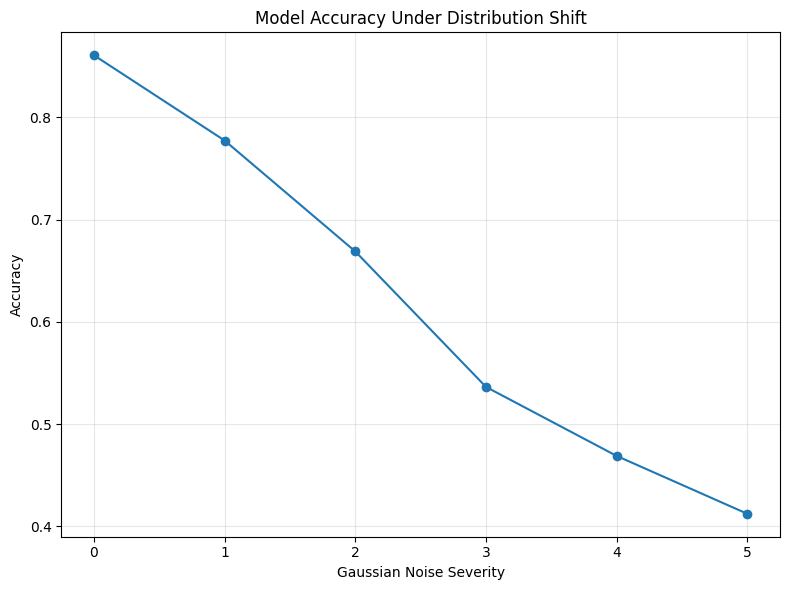

Saved: /content/selective-prediction-shift/figures/accuracy_vs_shift.png


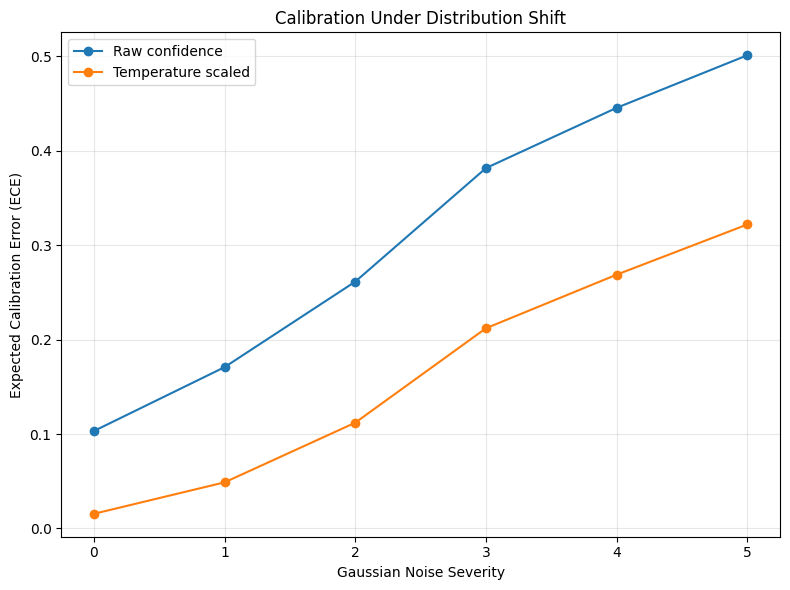

Saved: /content/selective-prediction-shift/figures/ece_vs_shift.png


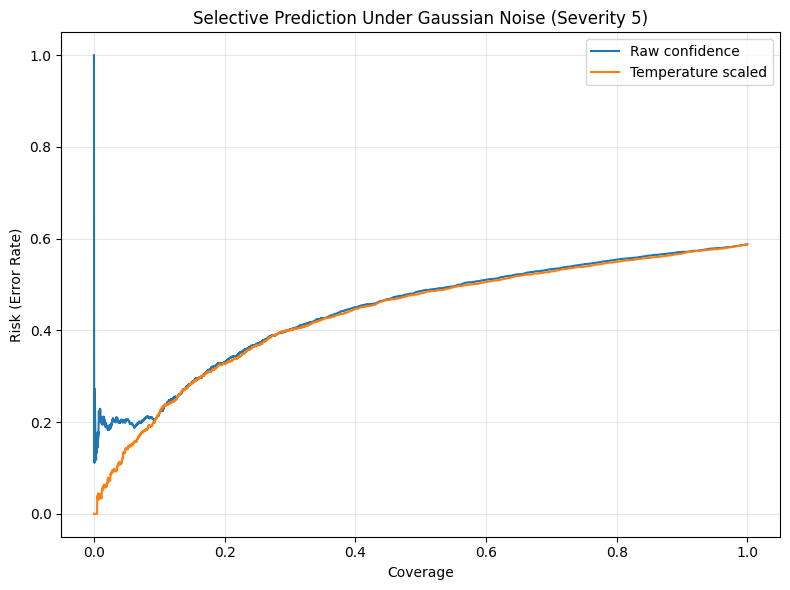

Saved: /content/selective-prediction-shift/figures/risk_coverage_severity5.png

All figures saved to:
/content/selective-prediction-shift/figures


In [37]:
import matplotlib.pyplot as plt
import os

fig_dir = "/content/selective-prediction-shift/figures"
os.makedirs(fig_dir, exist_ok=True)

severities = [0, 1, 2, 3, 4, 5]

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------

accuracy = [0.8608] + [
    r["accuracy"] for r in severity_results
]

raw_ece_values = [raw_clean_ece] + [
    r["raw_ece"] for r in severity_results
]

cal_ece_values = [cal_clean_ece] + [
    r["calibrated_ece"] for r in severity_results
]


# ---------------------------------------------------------
# Figure 1 — Accuracy vs severity
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    severities,
    accuracy,
    marker="o"
)

plt.xlabel("Gaussian Noise Severity")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Under Distribution Shift")
plt.xticks(severities)
plt.grid(alpha=0.3)

plt.tight_layout()

path = os.path.join(
    fig_dir,
    "accuracy_vs_shift.png"
)

plt.savefig(path, dpi=200)
plt.show()

print("Saved:", path)


# ---------------------------------------------------------
# Figure 2 — ECE vs severity
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    severities,
    raw_ece_values,
    marker="o",
    label="Raw confidence"
)

plt.plot(
    severities,
    cal_ece_values,
    marker="o",
    label="Temperature scaled"
)

plt.xlabel("Gaussian Noise Severity")
plt.ylabel("Expected Calibration Error (ECE)")
plt.title("Calibration Under Distribution Shift")
plt.xticks(severities)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

path = os.path.join(
    fig_dir,
    "ece_vs_shift.png"
)

plt.savefig(path, dpi=200)
plt.show()

print("Saved:", path)


# ---------------------------------------------------------
# Figure 3 — Risk–coverage at severity 5
# ---------------------------------------------------------

# Reuse the severity-5 logits already evaluated earlier
# by loading them once more.

severity_5_dataset = load_dataset(
    "WNJXYK/TTA-CIFAR-10-C",
    "gaussian_noise",
    split="severity_5"
)

severity_5_wrapped = CIFAR10CWrapper(severity_5_dataset)

severity_5_loader = DataLoader(
    severity_5_wrapped,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

logits_5, labels_5 = collect_logits(
    model,
    severity_5_loader,
    device
)

conf_5, preds_5, correct_5 = get_confidence(
    logits_5,
    labels_5
)

cal_logits_5 = logits_5 / T
cal_probs_5 = F.softmax(cal_logits_5, dim=1)

cal_conf_5, cal_preds_5 = cal_probs_5.max(dim=1)
cal_correct_5 = cal_preds_5.eq(labels_5)

raw_cov_5, raw_risk_5 = risk_coverage_curve(
    conf_5,
    correct_5
)

cal_cov_5, cal_risk_5 = risk_coverage_curve(
    cal_conf_5,
    cal_correct_5
)

plt.figure(figsize=(8, 6))

plt.plot(
    raw_cov_5,
    raw_risk_5,
    label="Raw confidence"
)

plt.plot(
    cal_cov_5,
    cal_risk_5,
    label="Temperature scaled"
)

plt.xlabel("Coverage")
plt.ylabel("Risk (Error Rate)")
plt.title(
    "Selective Prediction Under Gaussian Noise "
    "(Severity 5)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

path = os.path.join(
    fig_dir,
    "risk_coverage_severity5.png"
)

plt.savefig(path, dpi=200)
plt.show()

print("Saved:", path)

print("\nAll figures saved to:")
print(fig_dir)

In [38]:
import os

project_dir = "/content/selective-prediction-shift"

for root, dirs, files in os.walk(project_dir):
    level = root.replace(project_dir, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in sorted(files):
        print(f"{indent}  {file}")

selective-prediction-shift/
  results_summary.json
  figures/
    accuracy_vs_shift.png
    ece_vs_shift.png
    risk_coverage_severity5.png
  data/
    CIFAR-10-C.tar
    cifar-10-python.tar.gz
    cifar-10-batches-py/
      batches.meta
      data_batch_1
      data_batch_2
      data_batch_3
      data_batch_4
      data_batch_5
      readme.html
      test_batch
    cifar10-c/


In [39]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".ipynb"):
            print(os.path.join(root, file))